<a href="https://colab.research.google.com/github/vishal7379/Colab/blob/main/BE_project_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision pandas opencv-python

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "vishlthorat",\r\n  "key": "KGAT_4e0c264d6c4968cf0f656520fef086af"\r\n}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d bratjay/ua-detrac-orig
!unzip -q ua-detrac-orig.zip

Dataset URL: https://www.kaggle.com/datasets/bratjay/ua-detrac-orig
License(s): unknown
100% 9.23G/9.23G [01:45<00:00, 94.1MB/s]



In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/DETRAC-Images/DETRAC-Images")[:10])  # should show imgXXXXX.jpg

['.config', 'ua-detrac-orig.zip', 'DETRAC-MOT-toolkit', 'DETRAC-Train-Annotations-XML', 'DETRAC-Images', 'kaggle.json', 'DETRAC-Test-Annotations-XML', 'sample_data']
['MVI_63521', 'MVI_40204', 'MVI_40864', 'MVI_63552', 'MVI_39851', 'MVI_40241', 'MVI_40774', 'MVI_40192', 'MVI_40162', 'MVI_20061']


In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    rows = []

    folder_name = os.path.basename(xml_file).replace(".xml", "")

    for frame in root.findall('frame'):
        frame_id = int(frame.attrib['num'])
        img_name = f"img{frame_id:05d}.jpg"

        for target in frame.find('target_list'):
            box = target.find('box')

            xmin = float(box.attrib['left'])
            ymin = float(box.attrib['top'])
            xmax = xmin + float(box.attrib['width'])
            ymax = ymin + float(box.attrib['height'])

            rows.append({
                "folder": folder_name,
                "image": img_name,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax
            })

    return pd.DataFrame(rows)

In [ ]:
import os

img_root = "/content/DETRAC-Images/DETRAC-Images"

image_map = {}

for folder in os.listdir(img_root):
    folder_path = os.path.join(img_root, folder)

    for img in os.listdir(folder_path):
        if img not in image_map:
            image_map[img] = []

        image_map[img].append(os.path.join(folder_path, img))

print("Total unique image names:", len(image_map))

Total unique image names: 2635


In [ ]:
all_data = []

xml_folder = "/content/DETRAC-Train-Annotations-XML/DETRAC-Train-Annotations-XML"

for xml_file in os.listdir(xml_folder):
    if xml_file.endswith(".xml"):
        df = parse_xml(os.path.join(xml_folder, xml_file))
        all_data.append(df)

final_df = pd.concat(all_data)
final_df.to_csv("train.csv", index=False)

print("CSV created:", final_df.shape)

CSV created: (598281, 6)


In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

valid_rows = []

for _, row in df.iterrows():
    img_name = row['image']

    if img_name in image_map:
        # take first matching path
        row['path'] = image_map[img_name][0]
        valid_rows.append(row)

clean_df = pd.DataFrame(valid_rows)

clean_df.to_csv("train_clean.csv", index=False)

print("Original:", df.shape)
print("Clean:", clean_df.shape)

Original: (598281, 6)
Clean: (598281, 7)


In [ ]:
import torch
import cv2
from torch.utils.data import Dataset

class DetracDataset(Dataset):
    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)
        self.image_ids = self.df['image'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        records = self.df[self.df['image'] == image_id]

        img_path = records.iloc[0]['path']   # 🔥 use direct path

        img = cv2.imread(img_path)

        if img is None:
            raise Exception(f"Image not found: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.tensor(img / 255.0, dtype=torch.float32).permute(2,0,1)

        boxes = []
        labels = []

        for _, row in records.iterrows():
            boxes.append([row['xmin'], row['ymin'], row['xmax'], row['ymax']])
            labels.append(1)  # single class

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target

In [ ]:
from torch.utils.data import DataLoader

dataset = DetracDataset("train_clean.csv")

# 🔥 IMPORTANT: use subset (else colab will crash)
subset_size = min(5000, len(dataset))
dataset = torch.utils.data.Subset(dataset, range(subset_size))

loader = DataLoader(dataset, batch_size=2, shuffle=True,
                    collate_fn=lambda x: tuple(zip(*x)))

In [ ]:
from google.colab import files

uploaded = files.upload()

checkpoint_path = list(uploaded.keys())[0]

print("Loaded:", checkpoint_path)

Saving model_epoch_8.pth to model_epoch_8.pth
Loaded: model_epoch_8.pth


In [ ]:
from google.colab import files
uploaded = files.upload()

model_path = list(uploaded.keys())[0]
print("Model:", model_path)

KeyboardInterrupt: 

In [ ]:
import torch
import torchvision

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# create model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

# load weights
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.to(device)
model.train()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 166MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.00003)

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)



best_loss = float('inf')

for epoch in range(9,15):
    model.train()
    total_loss = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch}, Loss: {total_loss}")

    # save every epoch
    torch.save(model.state_dict(), f"model_epoch_{epoch}.pth")

    # save best
    if total_loss < best_loss:
        best_loss = total_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("🔥 Best model updated!")

Epoch 9, Loss: 1651.1866674274206
🔥 Best model updated!
Epoch 10, Loss: 1527.0981152653694
🔥 Best model updated!
Epoch 11, Loss: 1460.4490334391594
🔥 Best model updated!
Epoch 12, Loss: 1411.5318510904908
🔥 Best model updated!
Epoch 13, Loss: 1370.1876514069736
🔥 Best model updated!
Epoch 14, Loss: 1335.5387202650309
🔥 Best model updated!


In [ ]:
torch.save(model.state_dict(), "traffic_model.pth")

In [ ]:
from google.colab import files

uploaded = files.upload()

# get uploaded file name
image_path = list(uploaded.keys())[0]

print("Uploaded:", image_path)

Saving Screenshot 2026-05-02 154746.jpg to Screenshot 2026-05-02 154746.jpg
Uploaded: Screenshot 2026-05-02 154746.jpg


In [ ]:
import cv2
import matplotlib.pyplot as plt

from torchvision.ops import nms

def predict_uploaded(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_tensor = torch.tensor(img_rgb / 255.0, dtype=torch.float32).permute(2,0,1).to(device)

    with torch.no_grad():
        pred = model([img_tensor])[0]

    boxes = pred['boxes'].cpu()
    scores = pred['scores'].cpu()

    keep = nms(boxes, scores, iou_threshold=0.2)

    boxes = boxes[keep].numpy()
    scores = scores[keep].numpy()

    count = 0

    for box, score in zip(boxes, scores):
        if score > 0.9:
            x1, y1, x2, y2 = map(int, box)

            area = (x2 - x1) * (y2 - y1)

            if area > 50000:
                continue

            count += 1
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(10,6))
    plt.imshow(img_rgb)
    plt.title(f"Vehicles: {count}")
    plt.axis('off')

    return count

In [ ]:
def traffic_level(count):
    if count < 10:
        return "LOW"
    elif count < 30:
        return "MEDIUM"
    else:
        return "HIGH"

In [ ]:
from torchvision.ops import nms
import torch

# boxes_tensor = torch.tensor(boxes)
# scores_tensor = torch.tensor(scores)

# keep = nms(boxes_tensor, scores_tensor, iou_threshold=0.3)

# boxes = boxes_tensor[keep].numpy()
# scores = scores_tensor[keep].numpy()

Vehicle Count: 7
Traffic Level: LOW


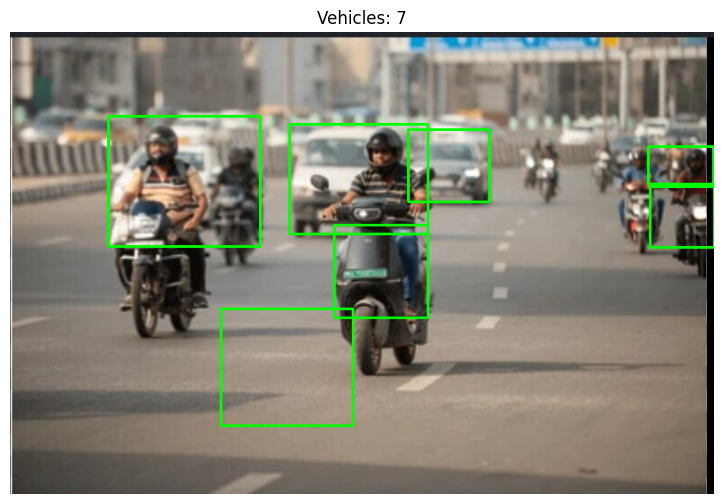

In [ ]:
model.eval()   # 🔥 ADD THIS LINE

count = predict_uploaded(image_path)

level = traffic_level(count)

print("Vehicle Count:", count)
print("Traffic Level:", level)

In [ ]:
from google.colab import files

files.download("model_epoch_14.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>